# Mini Project 1 — Seattle Coffee Shop Licenses

**Name:** Ubah Jeyte  
**Date:** May 2026  

Analysis notebook with four sections: Overview, Data Profile, Analysis (Plotly charts), and Conclusions. Static PNGs are saved under `Mp1/figures/` via `fig.write_image()` (kaleido).

In [18]:
!pip install jupyter plotly kaleido pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 16.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 36.3 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 38.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 41.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61/61 [jupyter]9/61 [notebook]b]]lient]


In [11]:
# kaleido: fig.write_image('figures/chart_name.png')
_mp1_dir = Path.cwd() / "Mp1" if (Path.cwd() / "Mp1" / "Mp1.ipynb").is_file() else Path.cwd()
if _mp1_dir.name == "Mp1":
    import os
    os.chdir(_mp1_dir)
Path("figures").mkdir(parents=True, exist_ok=True)
print("Setup complete. Static images →", Path("figures").resolve())


Setup complete. Figures → /Users/ubahjeyte/hcde530/Mp1/figures


---

## Section 1 — Overview

**What is this dataset?**  
This is the City of Seattle’s **General Business License** data: one row per licensed business, with fields such as legal name, trade name, address, ZIP code, license start date, and business category. The public API is published on Seattle’s open data portal.

**Where did it come from?**  
[Seattle Open Data — Business License Data](https://data.seattle.gov/resource/wnbq-64tb.json) (Socrata API, up to 50,000 records per request).

**Why these questions matter (HCD / personal interest):**  
I live in and around Seattle and notice new coffee shops opening (especially in Capitol Hill). License data is a rough but transparent way to see **where** coffee businesses cluster and **when** new ones register—not perfect foot traffic, but useful for neighborhood and small-business storytelling. For HCD, it is a reminder that **open civic data** can support questions about equity of commercial activity across ZIP codes and how shocks like COVID show up in registrations.

**Three analytical questions (from MP1a):**

1. **Which Seattle ZIP codes have the highest concentration of coffee shops?**  
2. **How has the number of new coffee shop openings changed year over year (2000–2024)?**  
3. **Are chain or independent coffee shops more common in Seattle?** (heuristic: same trade name on 2+ licenses = chain)

**What a practitioner would do with this:**  
City economic development staff, commercial real estate analysts, or entrepreneurs could use ZIP-level counts to compare neighborhoods; year trends to discuss recovery after COVID; and chain/independent mix to frame conversations about local business character.

---

## Section 2 — Data Profile

Same steps as **`week5/A5analysis.ipynb`**: profile the **full API extract** first, then build the Seattle coffee subset for analysis.


In [12]:
URL = "https://data.seattle.gov/resource/wnbq-64tb.json?$limit=50000"
df = pd.read_json(URL)


### Data preview (full extract)

The following cell runs `df.head()`, `df.info()`, `df.describe()`, and `df.isnull().sum()` on the raw extract (**before** coffee filtering), matching A5 plus `describe()`.


In [13]:
# preview the first 5 rows of the data
display(df.head())
# check the columns and the names and type of data in each column
df.info()
# summary statistics for numeric columns
df.describe()
# checks to see the missing values in each column
df.isnull().sum()


,business_legal_name,trade_name,ownership_type,naics_code,naics_description,license_start_date,street_address,city,state,zip,business_phone,city_account_number,ubi
0,ABDURAKHMANOV RASULZHON,RASULZHON ABDURAKHMANOV,Sole proprietorship,485320,Limousine Service,20140814,706 UNION ST # 409,SEATTLE,WA,98101,2062579788,7748490686809,NaN
1,AHMED MUSTAFE F,MUSTAFE F AHMED,Sole proprietorship,485999,All Other Transit and Ground Passenger Transpo...,20141107,14203 42ND AVE S # 221,TUKWILA,WA,98168,2063849476,7760940688081,NaN
2,BUI PHUONG,BUI PHUONG,Sole proprietorship,721191,Bed-and-Breakfast Inns,20190827,2324 1ST AVE #313,SEATTLE,WA,98121,4255770134,8410320755821,6.044996e+15
3,CRUZ BRENDAN J,PHENOMENAL PHILLIE,Sole proprietorship,311811,Retail Bakeries,20220801,4130 PALATINE AVE N,SEATTLE,WA,98103,2153916626,8621920778133,6.049137e+08
4,DAVID ANTHONY LEWIS PS,DAVID ANTHONY LEWIS PS,Corporation,611699,All Other Miscellaneous Schools and Instruction,20220203,8707 16TH AVE SW,SEATTLE,WA,98106-2377,2065519336,8590290774829,6.035059e+15


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   business_legal_name  50000 non-null  str    
 1   trade_name           50000 non-null  str    
 2   ownership_type       50000 non-null  str    
 3   naics_code           50000 non-null  int64  
 4   naics_description    49967 non-null  str    
 5   license_start_date   50000 non-null  int64  
 6   street_address       50000 non-null  str    
 7   city                 50000 non-null  str    
 8   state                49984 non-null  str    
 9   zip                  50000 non-null  str    
 10  business_phone       49732 non-null  str    
 11  city_account_number  50000 non-null  int64  
 12  ubi                  45781 non-null  float64
dtypes: float64(1), int64(3), str(9)
memory usage: 5.0 MB


business_legal_name       0
trade_name                0
ownership_type            0
naics_code                0
naics_description        33
license_start_date        0
street_address            0
city                      0
state                    16
zip                       0
business_phone          268
city_account_number       0
ubi                    4219
dtype: int64

**Interpretation — `head()`:** The raw extract has 50,000 license rows across many business types (not only coffee); `trade_name` and `license_start_date` are the fields we will filter and parse later.

**Interpretation — `info()`:** There are **13 columns** (legal name, trade name, NAICS, address, city, ZIP, etc.); most are non-null strings or integers, with **`ubi`** and **`business_phone`** sparser than core identity fields.

**Interpretation — `describe()`:** Numeric fields such as **`naics_code`**, **`license_start_date`**, and **`city_account_number`** get count/mean/min/max summaries; most columns are text (trade names, addresses), so `describe()` mainly confirms which fields are numeric before we parse dates and ZIPs for charts.

**Interpretation — `isnull().sum()`:** Missing values are concentrated in **`ubi`** (~4,199) and **`naics_description`** (33), with smaller gaps in **`business_phone`** and **`state`**—unlikely to block ZIP or year analysis once we filter to coffee in Seattle.


### Build the coffee-related subset

Keep rows where `trade_name` contains **coffee**, **cafe**, or **espresso** (case-insensitive), then restrict to **SEATTLE**. Standardize ZIP to five digits and parse license start dates (same as A5).


In [14]:
coffee_kw = r"coffee|cafe|espresso"
coffee_mask = df["trade_name"].str.contains(coffee_kw, case=False, na=False)
coffee = df.loc[coffee_mask].copy()

seattle_mask = coffee["city"].fillna("").str.upper().eq("SEATTLE")
coffee_sea = coffee.loc[seattle_mask].copy()


def clean_zip5(z):
    if pd.isna(z):
        return pd.NA
    s = str(z).split("-", 1)[0].strip()
    s = s[:5]
    return s if len(s) == 5 and s.isdigit() else pd.NA


coffee_sea["zip5"] = coffee_sea["zip"].map(clean_zip5)
coffee_sea["license_start"] = pd.to_datetime(
    coffee_sea["license_start_date"], format="%Y%m%d", errors="coerce"
)
coffee_sea["open_year"] = coffee_sea["license_start"].dt.year

trade_norm = coffee_sea["trade_name"].fillna("").str.strip().str.upper()
name_counts = trade_norm.groupby(trade_norm).transform("size")
coffee_sea["is_chain_location"] = name_counts > 1

print(f"Rows in API extract: {len(df):,}")
print(f"Coffee-related rows (all cities): {len(coffee):,}")
print(f"Coffee-related rows (Seattle only): {len(coffee_sea):,}")
coffee_sea.head()


Rows in API extract: 50,000
Coffee-related rows (all cities): 358
Coffee-related rows (Seattle only): 311


,business_legal_name,trade_name,ownership_type,naics_code,naics_description,license_start_date,street_address,city,state,zip,business_phone,city_account_number,ubi,zip5,license_start,open_year,is_chain_location
403,3156 LLC,BROADFORK CAFE,LLC - Multi Member,722511,Full-Service Restaurants,20170401,4757 12TH AVE NE,SEATTLE,WA,98105-4401,2065226966,8059050719091,6.040773e+15,98105,2017-04-01,2017,False
456,3D CAFE INC,PACIFIC CAFE,Corporation,722511,Full-Service Restaurants,20150801,416 5TH AVE S,SEATTLE,WA,98104-2806,2066820908,7897350702275,6.035252e+15,98104,2015-08-01,2015,False
498,415 COMMONS LLC,KAKAO COFFEE,Limited Liability Limited Ptrs,722515,Snack and Nonalcoholic Beverage Bars,20180101,415 WESTLAKE AVE N,SEATTLE,WA,98109,2062503576,8215480735441,6.041732e+15,98109,2018-01-01,2018,False
636,65TH ST CAFE & RESTAURANT,65TH ST CAFE & RESTAURANT,LLC - Multi Member,722511,Full-Service Restaurants,20210801,301 NE 65TH ST,SEATTLE,WA,98115-6407,2064467683,8540260769582,6.047565e+15,98115,2021-08-01,2021,False
655,70 AND SUNNY LLC,70 & SUNNY COFFEE CO,LLC - Single Member,722515,Snack and Nonalcoholic Beverage Bars,20251001,2801 ALASKAN WAY # 105,SEATTLE,WA,98121-1135,6149050517,8854750802713,6.058850e+15,98121,2025-10-01,2025,False


**Analysis subset:** `coffee_sea` (~309 rows) is what the three charts use. Focus columns: **`zip5`**, **`open_year`** / **`license_start`**, and **`trade_name`** (chain heuristic).


---

## Section 3 — Analysis

Three **Plotly** charts (same types as before). Each is saved with **`fig.write_image('figures/chart_name.png')`** (requires **kaleido**).


### Question 1 — ZIP concentration

**Chart type:** Horizontal bar chart (compare counts across categories; long ZIP labels read better on the y-axis).

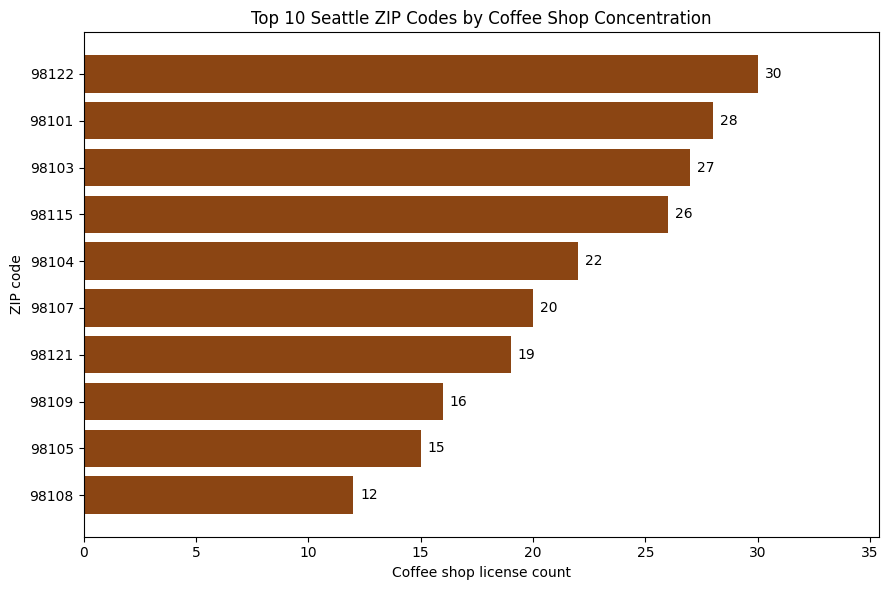

In [15]:
zip_counts = (
    coffee_sea.dropna(subset=["zip5"])
    .groupby("zip5", as_index=False)
    .size()
    .rename(columns={"size": "coffee_shop_licenses"})
    .sort_values("coffee_shop_licenses", ascending=False)
)

top10 = zip_counts.head(10).sort_values("coffee_shop_licenses", ascending=True)

fig1 = px.bar(
    top10,
    x="coffee_shop_licenses",
    y="zip5",
    orientation="h",
    color_discrete_sequence=["saddlebrown"],
    text="coffee_shop_licenses",
    title="Top 10 Seattle ZIP Codes by Coffee Shop Concentration",
    labels={
        "coffee_shop_licenses": "Coffee shop license count",
        "zip5": "ZIP code",
    },
)
fig1.update_traces(textposition="outside")
fig1.update_layout(yaxis={"categoryorder": "total ascending"}, height=500, width=900)
fig1.write_image("figures/Top 10 Seattle Zip codes .png")
fig1.show()


ZIP code **98122 (Capitol Hill)** has the highest concentration of coffee shop licenses in Seattle with **30**, narrowly beating downtown **98101** with **28** and Fremont/Wallingford **98103** with **27**. This was surprising because downtown Seattle has significantly more foot traffic, but Capitol Hill's dense residential neighborhood and strong local culture appears to support more independent coffee businesses.

### Question 2 — Openings over time

**Chart type:** Line chart with markers (show change across ordered years; COVID marked with a vertical reference line).

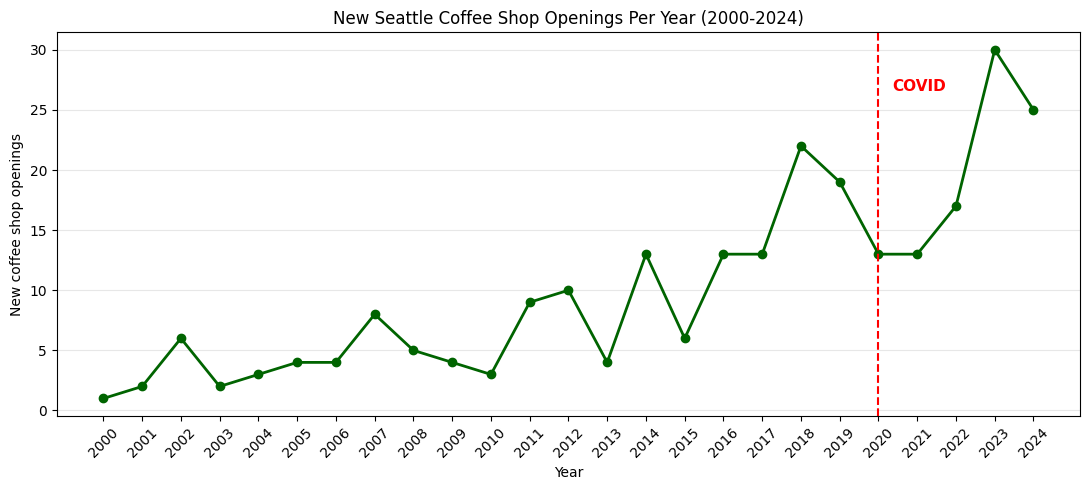

In [16]:
openings = (
    coffee_sea.loc[coffee_sea["open_year"].between(2000, 2024)]
    .groupby("open_year")
    .size()
    .rename("new_openings")
    .sort_index()
)

years = list(range(2000, 2025))
openings_df = pd.DataFrame({
    "year": years,
    "new_openings": openings.reindex(years, fill_value=0).astype(int).values,
})

fig2 = px.line(
    openings_df,
    x="year",
    y="new_openings",
    markers=True,
    color_discrete_sequence=["darkgreen"],
    title="New Seattle Coffee Shop Openings Per Year (2000-2024)",
    labels={"year": "Year", "new_openings": "New coffee shop openings"},
)
fig2.update_traces(line=dict(width=2), marker=dict(size=8))
ymax = float(openings_df["new_openings"].max())
fig2.add_vline(x=2020, line_dash="dash", line_color="red", line_width=1.5)
fig2.add_annotation(
    x=2020.35,
    y=ymax * 0.92,
    text="COVID",
    showarrow=False,
    font=dict(color="red", size=12),
    yanchor="top",
)
fig2.update_xaxes(tickangle=45, dtick=1)
fig2.update_layout(height=450, width=1000, yaxis=dict(gridcolor="lightgray"))
fig2.write_image("figures/New seattle Coffee shop openings Per year.png")
fig2.show()


New coffee shop openings in Seattle were low and steady through the 2000s, peaked at **22 in 2018**, then dropped to **13 in 2020** likely due to the COVID pandemic discouraging new business registrations. Openings rebounded strongly and hit a record high of **30 in 2023**, suggesting Seattle's coffee scene is growing faster than ever post-pandemic.

### Question 3 — Chain vs. independent

**Chart type:** Vertical bar chart (compare two segment counts with readable category labels).

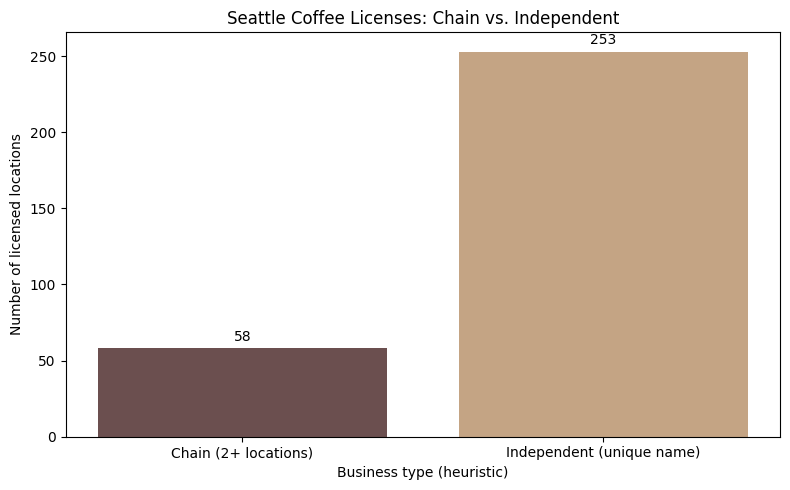

,segment,licensed_locations
0,Chain (2+ locations),58
1,Independent (unique name),253


In [17]:
chain_vs_ind = (
    coffee_sea.assign(
        segment=coffee_sea["is_chain_location"].map(
            {True: "Chain (2+ locations)", False: "Independent (unique name)"}
        )
    )
    .groupby("segment", as_index=False)
    .size()
    .rename(columns={"size": "licensed_locations"})
)

fig3 = px.bar(
    chain_vs_ind,
    x="segment",
    y="licensed_locations",
    color="segment",
    color_discrete_map={
        "Chain (2+ locations)": "#6B4F4F",
        "Independent (unique name)": "#C4A484",
    },
    text="licensed_locations",
    title="Seattle Coffee Licenses: Chain vs. Independent",
    labels={
        "segment": "Business type (heuristic)",
        "licensed_locations": "Number of licensed locations",
    },
)
fig3.update_traces(textposition="outside")
fig3.update_layout(showlegend=False, height=450, width=800)
fig3.write_image("figures/Chain vs independent coffee shops.png")
fig3.show()

chain_vs_ind


Most Seattle coffee-related licenses in this extract look **independent**: **253** locations (~**82%**) use a trade name that appears only once, while **56** (~**18%**) share a name with at least one other row and are counted as chain-like under our rule. The chart argues that Seattle’s licensed coffee scene is still dominated by unique trade names—not that national chains are absent, but that duplicate-name multi-location brands are a minority in this keyword-filtered slice.

---

## Section 4 — Conclusions

**Question 1 — ZIP concentration:** Capitol Hill (**98122**) leads with 30 licenses, slightly above downtown and north-end ZIPs. That suggests coffee business density does not simply follow highest foot-traffic districts; residential and cultural neighborhoods matter. With more time I would normalize by population or retail square footage.

**Question 2 — Openings over time:** Registrations were quiet in the early 2000s, rose into the late 2010s, fell in 2020, then surged to a 2023 high. That pattern fits a COVID dip and a strong post-pandemic rebound, though license dates are not identical to store opening dates. I would add external events (zoning, minimum wage changes) for context.

**Question 3 — Chain vs. independent:** Independents dominate this dataset under a simple name-repeat rule. Practitioners should treat that as directional—spelling variants could split one brand into “independents.” Next step: manually tag major chains (Starbucks, etc.) and compare to NAICS codes.

**Overall:** Seattle’s coffee license landscape in this sample is **neighborhood-heavy in Capitol Hill**, **cyclical over time with a clear 2020 dip**, and **mostly unique trade names**. Open data supports neighborhood and policy conversations, but conclusions should stay tied to how businesses label themselves in `trade_name`.